# **Modelling**

## Objectives

* Load the cleaned dataset used in the EDA notebook
* Build baseline single-feature models to establish a floor before comparing full models
* Build and compare Logistic Regression and Random Forest models to predict Attrition
* Check which features the Random Forest model relies on most
* Check whether the Random Forest model performs fairly across Gender and MaritalStatus

This directly answers Business Requirement 4: can attrition be predicted using employee demographic,
employment and workplace characteristics?


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/employee-attrition-hackathon/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/employee-attrition-hackathon'

# Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Load Clean Dataset

In [7]:
# Load the cleaned dataset in
df = pd.read_csv('data/clean/hr_attrition_clean.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 1470 rows, 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


---

### Prepare Data

we will be predicting Attrition from all remaining employee, employment and workplace features. Splitting the data into training and test sets, so the models can be evaluated on employees they haven't seen during training.

In [8]:
# Splitting the dataset into features and target variable
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1176, 30), Test: (294, 30)


Before building any models we will check the balance of the target variable in the training set since an imbalanced target could make accuracy a misleading metric on its own.

In [9]:
y_train.value_counts(normalize=True)

Attrition
No     0.838435
Yes    0.161565
Name: proportion, dtype: float64

The target is quite imbalanced around 84% stayed vs 16% left. This means a majority class baseline (always predicting 'No') will already score around 84% accuracy without learning anything. This is the bar any real model needs to clear and it also means accuracy alone won't tell me whether a model is actually useful.

In [10]:
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

Majority-class baseline accuracy: 0.8384


### Single Feature Models

I will train two separate models each using only one feature to establish a baseline before testing whether combining features improves performance. I'm using MonthlyIncome and Age as the two starting features since these are the numeric variables most strongly linked to attrition in the EDA and correlation checks.

In [11]:
# Training a Logistic Regression model using only the MonthlyIncome feature
model_income = LogisticRegression(max_iter=1000)
model_income.fit(X_train[['MonthlyIncome']], y_train)
income_preds = model_income.predict(X_test[['MonthlyIncome']])
income_acc = accuracy_score(y_test, income_preds)
print(f"MonthlyIncome only - Accuracy: {income_acc:.4f}")

MonthlyIncome only - Accuracy: 0.8401


In [12]:
# Training a Logistic Regression model using only the Age feature
model_age = LogisticRegression(max_iter=1000)
model_age.fit(X_train[['Age']], y_train)
age_preds = model_age.predict(X_test[['Age']])
age_acc = accuracy_score(y_test, age_preds)
print(f"Age only - Accuracy: {age_acc:.4f}")

Age only - Accuracy: 0.8401


Both single feature models score almost identically to the majority class baseline 83.8%. MonthlyIncome alone reaches 0.8401 and Age alone also reaches 0.8401. This looks disappointing at first, but it's actually expected given the class imbalance  a model can match the baseline just by leaning toward predicting 'No' for almost everyone without genuinely separating leavers from stayers. Accuracy on its own is hiding whether either feature is doing real work which is exactly why I'll switch to precision/recall once I get to the full model below.

## Combined-Feature Model

Now I will train a model using both MonthlyIncome and Age together to check whether combining them captures anything the single feature models missed.

In [13]:
# Training a Logistic Regression model using both features
model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train[['MonthlyIncome', 'Age']], y_train)
combined_preds = model_combined.predict(X_test[['MonthlyIncome', 'Age']])
combined_acc = accuracy_score(y_test, combined_preds)
print(f"MonthlyIncome + Age - Accuracy: {combined_acc:.4f}")

MonthlyIncome + Age - Accuracy: 0.8401


Combining MonthlyIncome and Age together gives the exact same accuracy as either feature alone (0.8401), Age is adding nothing on top of MonthlyIncome for this simple two feature model. This confirms two features alone evaluated on accuracy aren't enough to move the needle here. The next step is to test the full feature set (including the categorical columns like OverTime) and to look at precision/recall rather than just accuracy.

# Logistic Regression vs Random Forest

Now testing the full feature set including the categorical columns (OverTime, Department, JobRole etc.) to compare two models properly rather than just single numeric features.

In [14]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [ ]:
# Training a Logistic Regression Classifier
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
logreg_preds = logreg_pipeline.predict(X_test)
accuracy_score(y_test, logreg_preds)

0.8605442176870748

In [16]:
# Training a Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
accuracy_score(y_test, rf_preds)

0.8503401360544217

With the full feature set, Logistic Regression reaches 0.8605 and Random Forest reaches 0.8503 both a little above the 0.8384 baseline but neither jump looks dramatic on accuracy alone. Given what I found with the single-feature models. I don't trust accuracy here to tell the real story so I want to look at precision and recall for each class before deciding which model is actually better.

In [ ]:
# Checking precision, recall and f1-score for the Logistic Regression model
print(classification_report(y_test, logreg_preds))

              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [ ]:
# Checking precision, recall and f1-score for the Random Forest model
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

          No       0.86      0.98      0.92       247
         Yes       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294



This is where the two models actually separate. Random Forest has the higher raw accuracy but its recall on 'Yes' (catching people who actually left) is only 15%. it's mostly just predicting 'No' for almost everyone the same pattern as the single feature baselines. Logistic Regression has slightly lower accuracy but a much higher recall of 34% on the 'Yes' class, meaning it's actually identifying twice as many at-risk employees. Since the whole point of Business Requirement 4 is predicting who's at risk. **I'm going with Logistic Regression as the better model here even though its accuracy is lower**.

### Feature Importance

Checking which features the Random Forest model relied on most to see whether this matches what the EDA and correlation analysis suggested.

In [19]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(rf_pipeline.named_steps['classifier'].feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15)

num__MonthlyIncome              0.076761
num__Age                        0.061698
num__TotalWorkingYears          0.056192
num__DailyRate                  0.053835
num__HourlyRate                 0.045703
num__MonthlyRate                0.044013
num__DistanceFromHome           0.042017
num__YearsAtCompany             0.037543
num__YearsWithCurrManager       0.035799
num__NumCompaniesWorked         0.034644
num__PercentSalaryHike          0.032119
num__EnvironmentSatisfaction    0.028492
cat__OverTime_No                0.026554
num__WorkLifeBalance            0.026083
cat__OverTime_Yes               0.025581
dtype: float64

MonthlyIncome, Age and TotalWorkingYears dominate the importance ranking together with DailyRate and HourlyRate. This roughly matches H2 from the EDA notebook (income mattered) but also surfaces Age and tenure as bigger combined factors than I expected. OverTime, which was by far the strongest single factor result in the EDA (H1) ranks much lower here once every other feature is considered together worth noting as a genuine nuance rather than a contradiction single factor and combined factor importance don't always agree.

## Fairness Check by Subgroup

So far I've checked whether the data shows any bias in the EDA notebook nothing was tested directly on Gender or MaritalStatus. But that's a separate question from whether the model itself treats every group fairly. A model can be accurate overall while still performing noticeably worse for one particular group. So I want to check the Random Forest model's accuracy broken down by Gender and MaritalStatus.

In [20]:
results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = rf_preds
results_df['correct'] = results_df['actual'] == results_df['predicted']

print("Random Forest accuracy by Gender:")
print(results_df.groupby('Gender')['correct'].mean())

Random Forest accuracy by Gender:
Gender
Female    0.853448
Male      0.848315
Name: correct, dtype: float64


In [21]:
print("Random Forest accuracy by Marital Status:")
print(results_df.groupby('MaritalStatus')['correct'].mean())

Random Forest accuracy by Marital Status:
MaritalStatus
Divorced    0.906250
Married     0.879699
Single      0.773196
Name: correct, dtype: float64


Accuracy by Gender is close 85.3% (Female) vs 84.8% (Male) a gap small enough not to be concerning. Accuracy by MaritalStatus is a different story the model is noticeably less accurate for Single employees (77.3%) than for Divorced employees (90.6%) a gap of over 13 percentage points. This lines up with what I noticed in the EDA, single employees have a much higher attrition rate to begin with (25.0% vs 10.1% for divorced) so the model has more genuinely hard cases to get right in that group. This is worth flagging clearly in the README's Ethical Considerations section rather than treating it as an incidental detail.

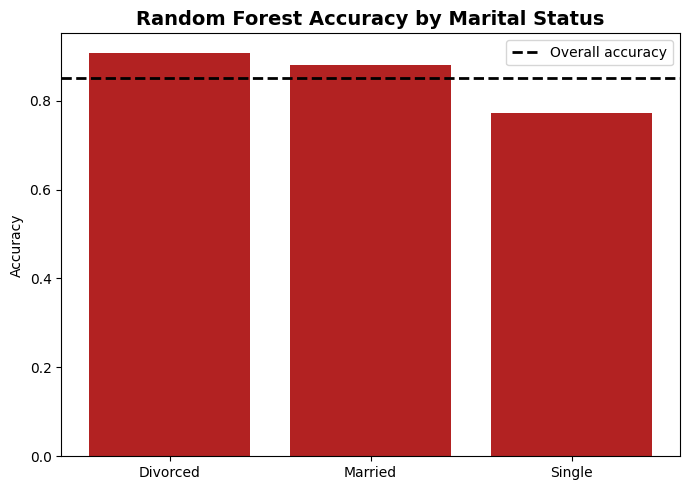

In [23]:
rf_acc = accuracy_score(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(7, 5))
marital_acc = results_df.groupby('MaritalStatus')['correct'].mean().sort_values(ascending=False)
ax.bar(marital_acc.index, marital_acc.values, color='firebrick')
ax.axhline(rf_acc, color='black', linestyle='--', linewidth=2, label='Overall accuracy')
ax.set_title('Random Forest Accuracy by Marital Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

### Model Comparison Summary

| Model | Accuracy | Recall (Yes) |
|---|---|---|
| Majority-class baseline | 0.8384 | 0.00 |
| MonthlyIncome only | 0.8401 | — |
| Age only | 0.8401 | — |
| Logistic Regression (full features) | 0.8605 | 0.34 |
| Random Forest (full features) | 0.8503 | 0.15 |

Logistic Regression is the model I'd recommend taking forward, it has both the highest accuracy and
more importantly for Business Requirement 4 more than double the recall on employees who actually left.

In [24]:
importances.sort_values(ascending=False).to_csv('data/clean/feature_importance.csv')

model_comparison = pd.DataFrame({
    'Model': ['Majority-class baseline', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [0.8384, 0.8605, 0.8503],
    'Recall_Yes': [0.00, 0.34, 0.15]
})
model_comparison.to_csv('Data/clean/model_comparison.csv', index=False)

marital_fairness = results_df.groupby('MaritalStatus')['correct'].mean().reset_index()
marital_fairness.to_csv('data/clean/fairness_by_maritalstatus.csv', index=False)

print("Results exported")

Results exported


---